In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido
from scipy.stats import linregress

plt.style.use("default")
sns.set_theme(style="whitegrid")



In [4]:


fund_master = pd.read_csv(
    r"D:\Bluestock-project\data\processed\01_fund_master_cleaned.csv"
)

nav = pd.read_csv(
    r"D:\Bluestock-project\data\processed\02_nav_history_cleaned.csv"
)

performance = pd.read_csv(
    r"D:\Bluestock-project\data\processed\07_scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    r"D:\Bluestock-project\data\processed\10_benchmark_indices_cleaned.csv"
)


In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

calculate_cagr

In [7]:
def calculate_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    subset = df[df["date"] >= start_date]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]
    end_nav = subset.iloc[-1]["nav"]

    return ((end_nav / start_nav) ** (1 / years)) - 1

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

cagr table

In [10]:
cagr_results = []

for code, grp in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(grp,1),
        "cagr_3yr": calculate_cagr(grp,3),
        "cagr_5yr": calculate_cagr(grp,5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

Sharpe Ratio

In [11]:
RF = 0.065

sharpe_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252

    annual_vol = returns.std() * np.sqrt(252)

    sharpe = (
        annual_return - RF
    ) / annual_vol

    sharpe_results.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

Sortino Ratio

In [12]:
sortino_results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = returns.mean() * 252

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

Benchmark Returns

In [13]:
nifty100 = benchmark[
    benchmark["index_name"]
    .str.contains(
        "NIFTY 100",
        case=False,
        na=False
    )
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [32]:
for name in benchmark["index_name"].unique():
    print(name)

NIFTY50
NIFTY100
NIFTY_MIDCAP150
BSE_SMALLCAP
NIFTY500
CRISIL_LIQUID
CRISIL_GILT


In [34]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [35]:
print(nifty100.shape)

(1150, 3)


In [36]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [39]:
nav["date"] = pd.to_datetime(nav["date"])

nifty100["date"] = pd.to_datetime(nifty100["date"])

In [40]:
print(nav["date"].dtype)
print(nifty100["date"].dtype)

datetime64[ns]
datetime64[ns]


In [41]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [42]:
code = nav["amfi_code"].iloc[0]

grp = nav[nav["amfi_code"] == code]

temp = grp[["date", "daily_return"]].merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(temp.shape)

(1150, 3)


Alpha & Beta

In [43]:
alpha_beta = []

for code, grp in nav.groupby("amfi_code"):

    temp = grp[["date", "daily_return"]].merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(temp) < 30:
        continue

    result = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "alpha": result.intercept * 252,
        "beta": result.slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [30]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [44]:
import os

os.makedirs(
    r"D:\Bluestock-project\reports",
    exist_ok=True
)

In [45]:
alpha_beta_df.to_csv(
    r"D:\Bluestock-project\reports\alpha_beta_df.csv",
    index=False
)

Maximum Drawdown

In [46]:
drawdown_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    trough_date = grp.loc[
        drawdown.idxmin(),
        "date"
    ]

    peak_date = grp.loc[
        :drawdown.idxmin(),
        "nav"
    ].idxmax()

    peak_date = grp.loc[
        peak_date,
        "date"
    ]

    drawdown_results.append({

        "amfi_code": code,

        "max_drawdown":
            max_dd,

        "peak_date":
            peak_date,

        "trough_date":
            trough_date
    })

drawdown_df = pd.DataFrame(
    drawdown_results
)

Tracking Error

In [47]:
tracking_error_results = []

for code, grp in nav.groupby("amfi_code"):

    temp = grp[
        ["date","daily_return"]
    ].merge(
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    temp = temp.dropna()

    te = (
        (temp["daily_return"]
         -
         temp["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": code,
        "tracking_error": te
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

In [48]:
print(alpha_beta_df.shape)

(40, 3)


Fund Scorecard

In [49]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(drawdown_df,on="amfi_code")
    .merge(
        fund_master[
            ["amfi_code",
             "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

In [50]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [51]:
scorecard["score"] = (

      0.30*scorecard["return_rank"]
    + 0.25*scorecard["sharpe_rank"]
    + 0.20*scorecard["alpha_rank"]
    + 0.15*scorecard["expense_rank"]
    + 0.10*scorecard["dd_rank"]

)

In [52]:
scorecard["score"] = (
    100 *
    (
        scorecard["score"]
        -
        scorecard["score"].min()
    )
    /
    (
        scorecard["score"].max()
        -
        scorecard["score"].min()
    )
)

In [53]:
import os

os.makedirs(
    r"D:\Bluestock-project\reports",
    exist_ok=True
)
scorecard.to_csv(
    r"D:\Bluestock-project\reports\fund_scorecard.csv",
    index=False
)

Benchmark Comparison Chart

In [55]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
)
top5

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,sharpe_ratio,alpha,beta,max_drawdown,peak_date,trough_date,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,score
7,102886,-0.167975,-0.007674,0.010303,UTI Mid Cap Fund - Regular - Growth,-0.205832,0.028969,-0.042125,-0.280011,2025-01-07,2026-04-27,1.51,37.0,36.0,40.0,24.5,35.0,100.000000
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,0.037476,-0.058268,-0.247344,2022-03-30,2022-09-15,1.55,35.0,35.0,39.0,32.0,34.0,99.913119
17,119095,-0.427976,-0.117058,0.013376,Axis Small Cap Fund - Regular - Growth,-0.075974,0.048016,-0.066951,-0.516778,2025-05-22,2026-05-11,1.38,40.0,33.0,37.0,17.0,39.0,95.916594
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,0.162661,0.108971,-0.065289,-0.354469,2024-11-21,2026-05-11,1.53,39.0,28.0,27.0,28.5,38.0,89.226759
14,119092,0.016091,0.005259,0.055826,Axis Bluechip Fund - Regular - Growth,0.030785,0.068995,0.009731,-0.144016,2023-10-12,2025-02-07,1.64,36.0,31.0,30.0,39.5,15.0,88.531712


In [56]:
end_date = nav["date"].max()

start_date = (
    end_date
    -
    pd.DateOffset(years=3)
)

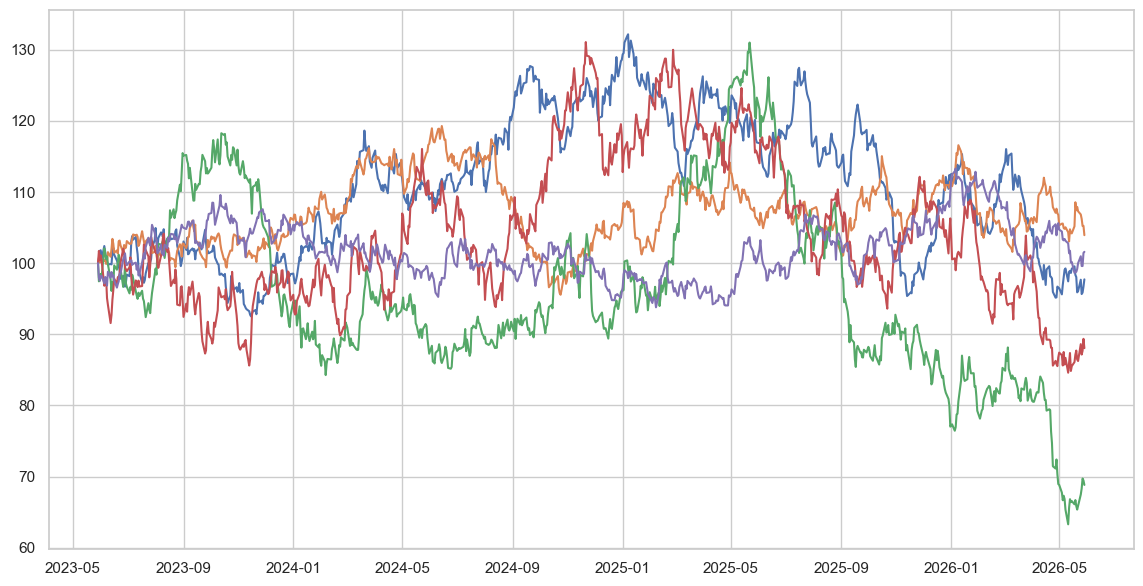

In [57]:
plt.figure(figsize=(14,7))

for code in top5["amfi_code"]:

    temp = nav[
        (nav["amfi_code"]==code)
        &
        (nav["date"]>=start_date)
    ].copy()

    temp["normalized"] = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=str(code)
    )

In [67]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100_chart = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()
nifty50 = nifty50[
    nifty50["date"] >= start_date
].sort_values("date")

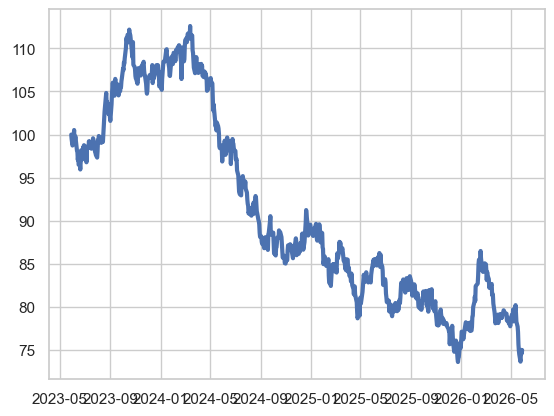

In [68]:

nifty50["normalized"] = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

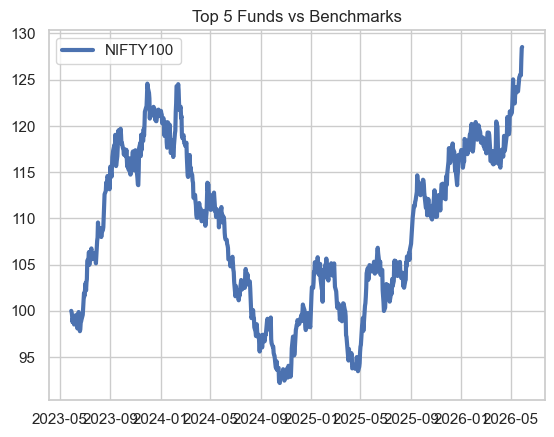

In [69]:
nifty100_chart = nifty100[
    nifty100["date"]>=start_date
].copy()

nifty100_chart["normalized"] = (
    nifty100_chart["close_value"]
    /
    nifty100_chart["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100_chart["date"],
    nifty100_chart["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()
plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()